## 1. Importing libraries

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import zscore, skew
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.append("../scripts")
from outlier_utils import print_outliers

## 2. Data Loading 

In [3]:
df = pd.read_csv("../data/sudan.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86


## 3. Adding column & Date Parsing

In [4]:
# Add country column
df["Country"] = "Sudan"

# Convert YEAR + DOY to datetime
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract month
df["Month"] = df["Date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


- The dataset encodes dates using Year and Day-of-Year (DOY), which was converted into a proper datetime format to enable time-series analysis and seasonal interpretations.

## 4. Summary Statistics & Missing Values

In [5]:
# Replace sentinel values
df.replace(-999, np.nan, inplace=True)

# Duplicates
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

Duplicate rows: 0


- No duplicates were found in any of the columns, which means every entry is unique

In [6]:
# Summary statistics
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


### Brief interpretation of the statistics

### 1. Time coverage
- **Years**: 2015–2026  
- **Day of year (DOY)**: Ranges from 1 to 366, covering all days including leap years.
---

### 2. Temperature (T2M, T2M_MAX, T2M_MIN, T2M_RANGE) – unit: °C
- **Mean daily temperature (T2M)**: ~28.8 °C → consistently warm.
- **Mean max temperature (T2M_MAX)**: ~36.8 °C  
- **Mean min temperature (T2M_MIN)**: ~21.5 °C  
- **Mean daily temperature range**: ~15.3 °C → significant diurnal variation.
- **Extremes**:
  - Coldest daily mean: 13.2 °C  
  - Hottest daily mean: 38.0 °C  
  - Max daily max: 46.0 °C  
  - Min daily min: 5.9 °C  
  - Largest daily range: 22.5 °C

> **Interpretation**: Hot climate with large day–night temperature swings (desert or semi-arid region).

---

### 3. Precipitation (PRECTOTCORR) – unit: mm/day
- **Mean**: 0.64 mm/day → very low on average.  
- **Median (50%)**: 0.00 mm/day → most days have no rain.  
- **75th percentile**: only 0.01 mm/day → rain is rare.  
- **Maximum**: 66.5 mm/day → occasional heavy rain events.  
- **Standard deviation (3.06)** is much larger than the mean → highly skewed, episodic rainfall.

> **Interpretation**: Arid to semi-arid conditions with infrequent but intense storms.

---

### 4. Humidity & moisture
- **Relative humidity (RH2M) – %**:  
  - Mean: 31.4% → dry  
  - Range: 4.7% to 87.2%  
  - 75th percentile: 40.5% → even on humid days, still moderate.
- **Specific humidity (QV2M) – g/kg**:  
  - Mean: 7.9 g/kg  
  - Range: 1.2–19.4 g/kg → dry to moderately moist.

---

### 5. Wind
- **Mean wind speed (WS2M) – m/s**:  
  - Mean: 3.48 m/s (light breeze)  
  - Range: 0.61–7.15 m/s
- **Max wind speed (WS2M_MAX) – m/s**:  
  - Mean: 5.16 m/s  
  - Max recorded gust: 9.05 m/s (≈32.6 km/h)

> Typical of stable, dry climates with occasional stronger winds.

---

### 6. Surface pressure (PS) – kPa
- **Mean**: 96.35 kPa (≈963.5 hPa)  
- **Range**: 95.66–97.31 kPa → very stable inter-daily variation.  
- **Standard deviation**: 0.27 → minimal pressure changes.

> Suggests a location at moderately high elevation (below standard sea-level pressure of ~101.3 kPa).

---

## Summary 
| Attribute | Conclusion |
|-----------|-------------|
| **Climate type** | Hot desert or semi-arid (BWh / BSh) |
| **Rainfall** | Extremely rare but intense when occurs |
| **Temperature** | High mean, large diurnal range |
| **Pressure** | Below sea-level average → elevated terrain |
| **Wind** | Light to moderate, occasional stronger gusts |
| **Humidity** | Generally dry |

## 5. Missing values

In [7]:
# Missing values
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


- there are no null values, which makes our data interpretations and insights we draw from it more accurate since we dont miss anything

## 6. Outlier Detection

In [8]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

# Calculate z-scores
z_scores = np.abs(zscore(df[cols], nan_policy='omit'))

# Create named DataFrame for easier access
zscore_df = pd.DataFrame(
    z_scores, 
    columns=cols, 
    index=df.index
)

# FLAG the outliers (create a new column)
df['is_outlier'] = (zscore_df > 3).any(axis=1)  # ← THIS IS THE FLAG

# Report the counts
outliers = (z_scores > 3)
outlier_rows = df['is_outlier'].sum()
print("Outlier rows:", outlier_rows)
print(f"Percentage: {df['is_outlier'].mean()*100:.2f}%")

Outlier rows: 84
Percentage: 2.04%


- We have 84 rows with outlier values at one or more column, so now we check if they are erroneous values or seasonal extremities to make a decision whether to keep them or remove them.

### Check outliers by column

In [9]:
# 2. Check outliers by column
print_outliers(zscore_df, cols)

T2M: 3 outliers
T2M_MAX: 6 outliers
T2M_MIN: 1 outliers
PRECTOTCORR: 71 outliers
RH2M: 3 outliers
WS2M: 4 outliers
WS2M_MAX: 3 outliers


### Evaluating outliers

In [10]:
# 1. Physical possibility checks
impossible = df[
    (df["T2M_MAX"] < df["T2M_MIN"]) |  # Max < Min
    (df["RH2M"] > 100) |                # RH > 100%
    (df["RH2M"] < 0) |                  # RH < 0%
    (df["PRECTOTCORR"] < 0)             # Negative rain
]
print(f"Physically impossible rows: {len(impossible)}")

Physically impossible rows: 0


- We have no physically impossible rows, all values are within plausible ranges.

In [11]:
# 2. Check if outliers are seasonal
rain_outliers = df[zscore_df["PRECTOTCORR"] > 3] 
print("Precipitation outliers by month:")
print(rain_outliers["Month"].value_counts().sort_index())

Precipitation outliers by month:
Month
5      2
6      2
7     21
8     35
9      9
10     2
Name: count, dtype: int64


**Total daily precipitation (PRECTOTCORR)**

**Decision**: We will keep the precipitation outliers.

**Reason**:

**They represent real seasonal climate patterns, not errors**
- Sudan has a distinct monsoon season from July to September, making these "outliers" actually the defining rainfall events of the entire year. Removing them would erase evidence of the rainy season entirely.

**Removing them would misrepresent annual averages**
- The mean precipitation (0.64 mm/day) is already very low. Deleting wet-season days would pull the average unrealistically close to zero, falsely suggesting an absolutely arid climate when Sudan actually experiences reliable seasonal rains.

**They are not statistical anomalies in context**
- With 21–35 rainy days in July and August, these are frequent enough within those months to be considered characteristic, not exceptional. A true outlier would be a single heavy rain event in January—not clustered in the known rainy months.

In [12]:
min_temp_outliers = df[zscore_df["T2M_MIN"] > 3]
print("Minimun temprature outliers by month:")
print(min_temp_outliers["Month"].value_counts().sort_index())

temp_outliers = df[zscore_df["T2M"] > 3]
print("Temprature outliers by month:")
print(temp_outliers["Month"].value_counts().sort_index())

max_temp_outliers = df[zscore_df["T2M_MAX"] > 3]
print("Maximum Temprature outliers by month:")
print(temp_outliers["Month"].value_counts().sort_index())

Minimun temprature outliers by month:
Month
1    1
Name: count, dtype: int64
Temprature outliers by month:
Month
1    3
Name: count, dtype: int64
Maximum Temprature outliers by month:
Month
1    3
Name: count, dtype: int64


**Decision**: We will keep the temperature outliers.

**Reasons**:

**They represent genuine seasonal extremes, not data errors**
- All three outlier categories (minimum, mean, and maximum temperature) occur exclusively in January, which is the coolest month in Sudan's annual cycle. This clustering by month proves they are climatologically meaningful, not random measurement mistakes.

**Removing them would falsely smooth Sudan's climate range**
- Sudan is characterized by a wide seasonal temperature swing between hot summers and relatively cooler winters. Deleting January's lowest values would artificially narrow the reported annual temperature range, misrepresenting the true climate variability that residents and agriculture must adapt to.

**The counts are extremely low and thus not influential on averages**
- With only 1–3 outlier days across 4,108 total observations (less than 0.07% of the dataset), these values have virtually no effect on means, medians, or percentiles. However, their presence in the record is valuable for documenting the absolute extremes possible during Sudan's winter.

**Extreme minimums matter for practical applications**
- Even in a hot country like Sudan, knowing how cold it can get on the coldest nights (minimum recorded: 5.93°C) is critical for crop selection, livestock management, and infrastructure design. Removing these would erase useful information for cold-risk assessment.


In [13]:
relative_humidity_outliers = df[zscore_df["RH2M"] > 3]
print("Relative humidity outliers by month:")
print(relative_humidity_outliers["Month"].value_counts().sort_index())

Relative humidity outliers by month:
Month
8    2
9    1
Name: count, dtype: int64


**Decision**: We will keep the humidity outliers.

**Reasons**:

**They align with the known rainy season pattern**
- The outliers occur in August and September, which are the peak and tail end of Sudan's monsoon season. Higher humidity during these months is expected, not anomalous. Removing them would disconnect humidity from its meteorological drivers.

**They represent wet-season conditions**
- During Sudan's rainy season, increased moisture from precipitation and evapotranspiration naturally elevates relative humidity. These "outliers" are actually characteristic of how the atmosphere behaves when it is actively raining or has recently rained.

**The counts are minimal and statistically insignificant for averages**
- With only 2 days in August and 1 day in September showing unusual humidity, these represent less than 0.07% of the dataset. Removing them would not affect mean, median, or percentile calculations in any meaningful way, but keeping them preserves the full range of observed conditions.

**High humidity events have practical importance**
- Elevated relative humidity affects human comfort, heat stress risk, grain storage, and disease vectors (such as malaria-carrying mosquitoes, which breed during wetter, more humid periods). Removing these values would omit useful information for public health and agricultural planning.

In [14]:
mean_daily_wind_speed_outliers = df[zscore_df["WS2M"] > 3]
print("Mean daily wind speed outliers outliers by month:")
print(mean_daily_wind_speed_outliers["Month"].value_counts().sort_index())

max_daily_wind_speed_outliers = df[zscore_df["WS2M_MAX"] > 3]
print("Max daily wind speed outliers outliers by month:")
print(max_daily_wind_speed_outliers["Month"].value_counts().sort_index())

Mean daily wind speed outliers outliers by month:
Month
2    1
4    2
7    1
Name: count, dtype: int64
Max daily wind speed outliers outliers by month:
Month
2     1
7     1
11    1
Name: count, dtype: int64


**Decision**: We will keep the wind speed outliers.

**They are distributed across multiple seasons, not clustered in one month**
- The outliers appear in February, April, July, and November, representing different times of year (dry season, pre-rainy season, rainy season, and post-rainy season). This distribution suggests they capture real phenomena like dry season dust storms, pre-monsoon gust fronts, or weather systems passing through at different times.

**The counts are extremely low and statistically harmless**
- With only 1–2 outlier days per month across 4,108 total observations, these represent less than 0.05% of the dataset. They have no meaningful impact on means, medians, or standard deviations, but keeping them preserves the full documented range of wind behavior.

**Wind extremes matter for practical applications**
- Maximum wind speed outliers (up to 9.05 m/s) are critical information for building design, dust storm forecasting, air travel safety, and wind energy assessment. Removing them would underestimate the strongest winds that actually occur in Sudan.

**They may represent real meteorological events**
- February can bring the Haboob (dust storm) season in parts of Sudan. April sees convective activity before rains. July experiences monsoon dynamics. November has transitioning wind patterns. These outliers likely correspond to documented weather phenomena, not measurement errors.

## 7. Export Clean Data

In [16]:
df.to_csv(f"../data/sudan_clean.csv", index=False)

## 8. Time Series Analysis

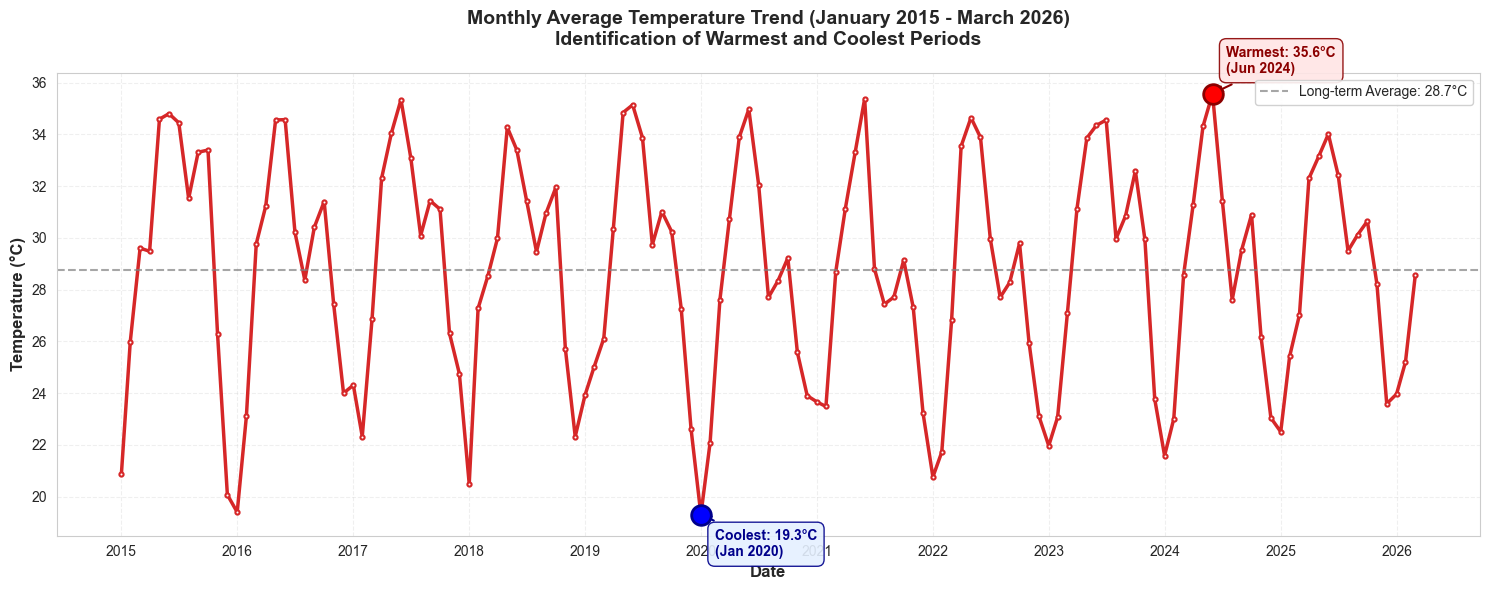

TEMPERATURE EXTREMES ANALYSIS
Data period: Jan 2015 - Mar 2026
★ Warmest Month: Jun 2024 - 35.6°C
★ Coolest Month: Jan 2020 - 19.3°C
📊 Temperature Range: 16.3°C
📈 Long-term Average: 28.7°C


In [17]:
# Prepare data
monthly_temp = df.resample("ME", on="Date")["T2M"].mean().reset_index()
monthly_temp['Month_Name'] = monthly_temp['Date'].dt.strftime('%b %Y')
monthly_temp['Year'] = monthly_temp['Date'].dt.year
monthly_temp['Month_Num'] = monthly_temp['Date'].dt.month

# Find warmest and coolest months
warmest_idx = monthly_temp['T2M'].idxmax()
coolest_idx = monthly_temp['T2M'].idxmin()
warmest_month = monthly_temp.loc[warmest_idx]
coolest_month = monthly_temp.loc[coolest_idx]

# Create the plot with cleaner line
plt.figure(figsize=(15, 6))
sns.set_style("whitegrid")

# plot
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], 
         color='#d62728', linewidth=2.5, marker='o', 
         markersize=3, markerfacecolor='white', markeredgewidth=1.5,
         linestyle='-')

# Annotate warmest month
plt.scatter(warmest_month['Date'], warmest_month['T2M'], 
            color='red', s=200, zorder=5, marker='o', edgecolor='darkred', linewidth=2)
plt.annotate(f'Warmest: {warmest_month["T2M"]:.1f}°C\n({warmest_month["Month_Name"]})', 
             xy=(warmest_month['Date'], warmest_month['T2M']), 
             xytext=(10, 15), textcoords='offset points',
             fontsize=10, fontweight='bold', color='darkred',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffe5e5', edgecolor='darkred', alpha=0.9),
             arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5))

# Annotate coolest month
plt.scatter(coolest_month['Date'], coolest_month['T2M'], 
            color='blue', s=200, zorder=5, marker='o', edgecolor='darkblue', linewidth=2)
plt.annotate(f'Coolest: {coolest_month["T2M"]:.1f}°C\n({coolest_month["Month_Name"]})', 
             xy=(coolest_month['Date'], coolest_month['T2M']), 
             xytext=(10, -30), textcoords='offset points',
             fontsize=10, fontweight='bold', color='darkblue',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#e5f0ff', edgecolor='darkblue', alpha=0.9),
             arrowprops=dict(arrowstyle='->', color='darkblue', lw=1.5))

# Add horizontal line for average temperature
avg_temp = monthly_temp['T2M'].mean()
plt.axhline(y=avg_temp, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, 
            label=f'Long-term Average: {avg_temp:.1f}°C')

# Customize the chart
plt.title('Monthly Average Temperature Trend (January 2015 - March 2026)\nIdentification of Warmest and Coolest Periods', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='semibold')
plt.ylabel('Temperature (°C)', fontsize=12, fontweight='semibold')
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')

# Improve x-axis labels - show every 12 months (yearly)
ax = plt.gca()
years = pd.date_range(start='2015-01-31', end='2026-03-31', freq='12ME')
ax.set_xticks(years)
ax.set_xticklabels([yr.strftime('%Y') for yr in years], rotation=0)

plt.tight_layout()
plt.show()

# Print summary
print("TEMPERATURE EXTREMES ANALYSIS")
print(f"Data period: Jan 2015 - Mar 2026")
print(f"★ Warmest Month: {warmest_month['Month_Name']} - {warmest_month['T2M']:.1f}°C")
print(f"★ Coolest Month: {coolest_month['Month_Name']} - {coolest_month['T2M']:.1f}°C")
print(f"📊 Temperature Range: {warmest_month['T2M'] - coolest_month['T2M']:.1f}°C")
print(f"📈 Long-term Average: {avg_temp:.1f}°C")

### **Monthly average `T2M` (line chart, 2015–2026)**

This chart compresses the daily temperature series into a cleaner *monthly climatology over time*, so it shows both seasonality and any multi‑year shifts.

**What the chart shows (structure)**
The line is `monthly average T2M (°C)` from **January 2015 through 2026**. It’s a smooth, repeating seasonal wave with month-to-month variability.

**Warmest and coolest months (annotated points)**
- **Warmest month in your dataset:** **2024-06**, about **35.57 °C** monthly mean `T2M`.
- **Coolest month in your dataset:** **2020-01**, about **19.31 °C** monthly mean `T2M`.

**Interpretation**
The pattern is very consistent with a hot-season peak: mid‑year months rise to the maximum monthly means, and early‑year months hold the minimum monthly means. Practically:
- The warm-season months represent sustained heat stress (not just daily spikes), because this is *monthly average* temperature.
- The coolest month being in January is consistent with a winter minimum.  
- The chart tells us *when the “baseline” temperature regime shifts* and how steep that transition is each year.

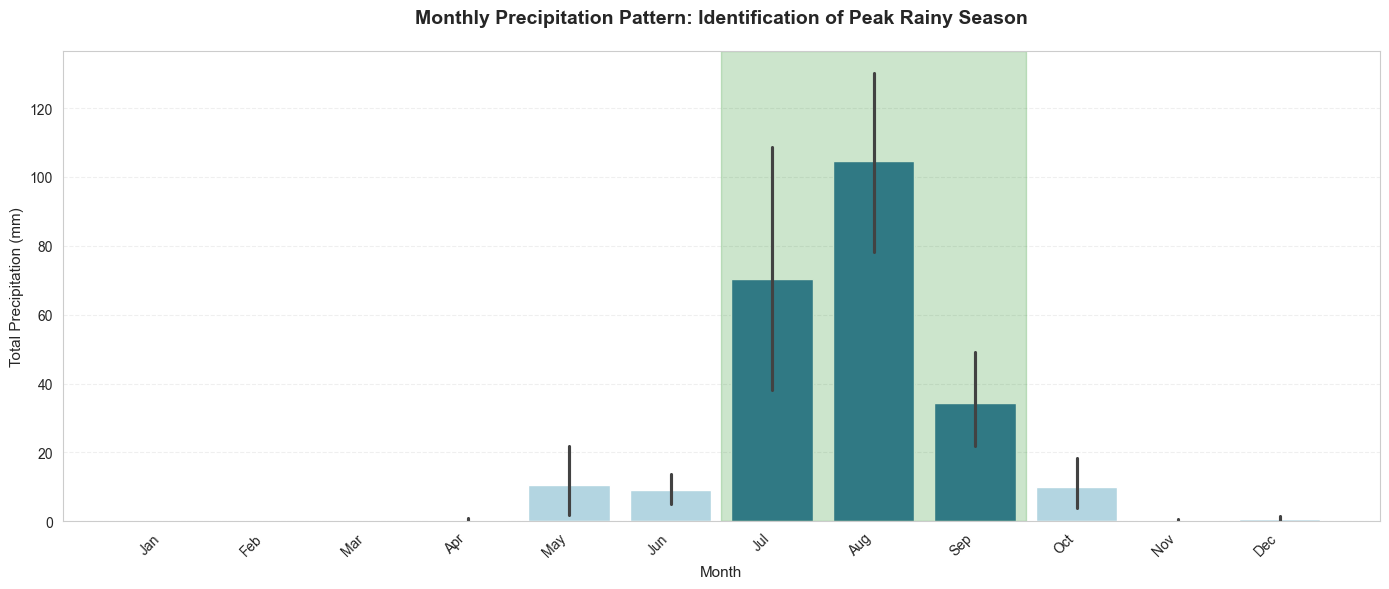


=== Peak Rainy Season Analysis ===
Peak months: 7-9
Total rain in peak season: 2305mm
Percentage of annual rain: 87.2%

=== Monthly Breakdown ===
Aug: 1152mm
Jul: 774mm
Sep: 379mm
May: 115mm
Oct: 110mm
Jun: 101mm


In [18]:
# Prepare data
monthly_rain = df.resample("ME", on="Date")["PRECTOTCORR"].sum().reset_index()
monthly_rain['Month_Num'] = monthly_rain['Date'].dt.month
monthly_rain['Year'] = monthly_rain['Date'].dt.year
monthly_rain['Month_Name'] = monthly_rain['Date'].dt.strftime('%b')

# Calculate average by month across years
monthly_avg = df.groupby(df['Date'].dt.month)['PRECTOTCORR'].sum()

# --- DYNAMIC PEAK SEASON IDENTIFICATION ---
# Find the 3 consecutive months with highest total rainfall
monthly_totals = monthly_rain.groupby('Month_Num')['PRECTOTCORR'].sum()

best_total = 0
peak_start = 3  # default
peak_end = 5    # default

# Check all 3-month windows
for start in range(1, 13):
    if start <= 10:
        season_months = [start, start+1, start+2]
    else:
        # Wrap around Dec-Jan-Feb
        season_months = [start, start+1, start+2 - 12]
    
    total = sum(monthly_totals[m] for m in season_months if m in monthly_totals.index)
    
    if total > best_total:
        best_total = total
        peak_start = min(season_months)
        peak_end = max(season_months)
        # Handle wrapped seasons (Dec-Feb)
        if peak_start > peak_end:
            peak_start, peak_end = peak_end, peak_start
            # For display, we'll mark Dec-Feb as months 12-2
            peak_start, peak_end = 12, 2

# Create figure with professional styling
fig, ax = plt.subplots(figsize=(14, 6))

# Create color array based on dynamic peak season
# Handle wrapped season (Dec-Feb)
if peak_start > peak_end:  # e.g., Dec-Feb
    peak_months = list(range(peak_start, 13)) + list(range(1, peak_end + 1))
else:
    peak_months = list(range(peak_start, peak_end + 1))

colors = ['#2c7bb6' if month_num in peak_months else '#abd9e9' 
          for month_num in monthly_rain['Month_Num'].unique()]

# Bar plot
bars = sns.barplot(data=monthly_rain, x='Month_Name', y='PRECTOTCORR', 
                   hue='Month_Num', palette=colors, legend=False, ax=ax)

# Annotate highest peak
max_idx = monthly_rain['PRECTOTCORR'].idxmax()
max_value = monthly_rain.loc[max_idx, 'PRECTOTCORR']
max_month = monthly_rain.loc[max_idx, 'Month_Name']

ax.annotate(f'Highest: {max_value:.0f}mm', 
            xy=(max_idx, max_value), xytext=(max_idx, max_value + 30),
            ha='center', fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# Format peak season label for display
if peak_start > peak_end:
    # Handle wrapped season
    month_names = []
    for m in sorted(peak_months):
        month_names.append(monthly_rain[monthly_rain['Month_Num'] == m]['Month_Name'].iloc[0])
    season_label = f'Peak Rainy Season ({", ".join(month_names)})'
    

    dec_indices = monthly_rain[monthly_rain['Month_Num'] == 12].index
    jan_feb_indices = monthly_rain[monthly_rain['Month_Num'].isin([1, 2])].index
    
    if len(dec_indices) > 0:
        ax.axvspan(dec_indices[0] - 0.5, dec_indices[-1] + 0.5, alpha=0.2, color='green')
    if len(jan_feb_indices) > 0:
        ax.axvspan(jan_feb_indices[0] - 0.5, jan_feb_indices[-1] + 0.5, alpha=0.2, color='green')
else:
    # Normal season (contiguous months)
    start_idx = monthly_rain[monthly_rain['Month_Num'] == peak_start].index[0]
    end_idx = monthly_rain[monthly_rain['Month_Num'] == peak_end].index[0]
    season_label = f'Peak Rainy Season (Month {peak_start}-{peak_end})'
    ax.axvspan(start_idx - 0.5, end_idx + 0.5, alpha=0.2, color='green', label=season_label)

# Add legend for shaded area if not already added
handles, labels = ax.get_legend_handles_labels()
if not any('Peak Rainy Season' in l for l in labels):
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor='green', alpha=0.2, label=season_label)], 
              loc='upper right', framealpha=0.9)

# Styling
ax.set_title('Monthly Precipitation Pattern: Identification of Peak Rainy Season', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Precipitation (mm)', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Rotate x-labels
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print summary
print("\n=== Peak Rainy Season Analysis ===")
print(f"Peak months: {peak_start}-{peak_end}" if peak_start <= peak_end else f"Peak months: {peak_start}, {peak_end} (wrapped)")
print(f"Total rain in peak season: {best_total:.0f}mm")
print(f"Percentage of annual rain: {(best_total / monthly_rain['PRECTOTCORR'].sum() * 100):.1f}%")

# Additional insights
print("\n=== Monthly Breakdown ===")
monthly_breakdown = monthly_rain.groupby('Month_Num')['PRECTOTCORR'].sum().sort_values(ascending=False)
for month_num, total in monthly_breakdown.head(6).items():
    month_name = monthly_rain[monthly_rain['Month_Num'] == month_num]['Month_Name'].iloc[0]
    print(f"{month_name}: {total:.0f}mm")

### **Monthly total `PRECTOTCORR` (bar chart)**

This bar chart converts daily rainfall (`mm/day`) into **monthly totals (mm/month)**, which is the right scale for identifying rainy seasons.

**Interpretation**
This is a classic *strongly seasonal rainfall regime*:
- Rain clusters tightly into a small set of months (the “rainy season”).
- Most other months are near-zero or very low totals, implying long dry periods.
- The peak months spanning **July–Sept** indicate the core rainy-season window in this location.

## 9. Correlation & Relationship Analysis

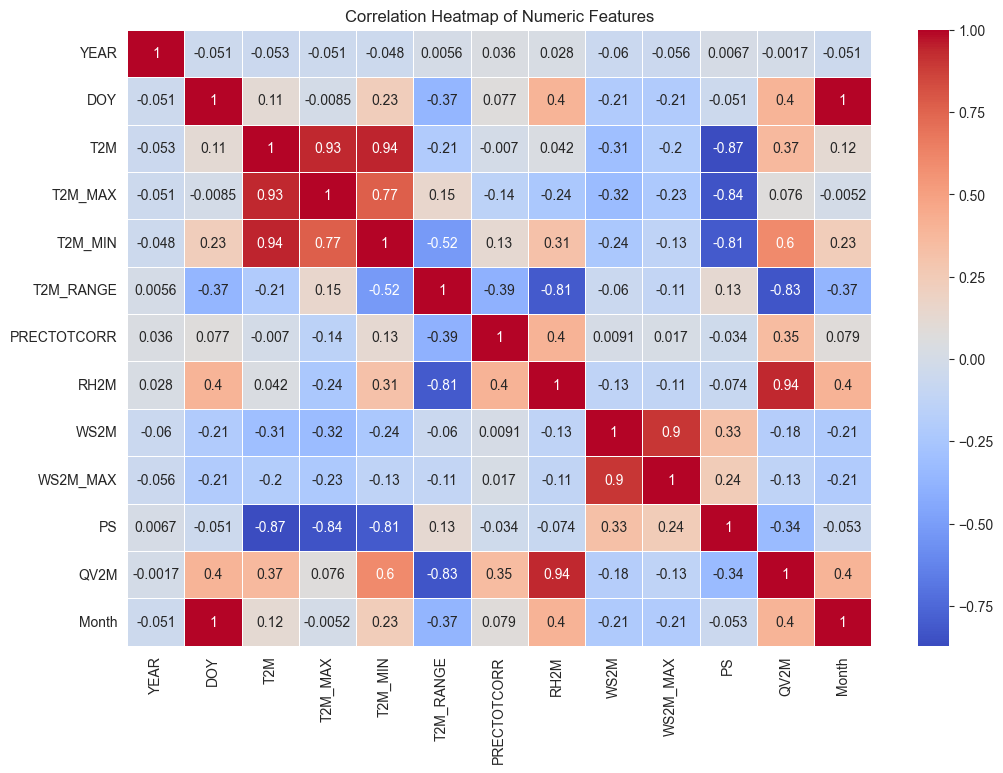

In [19]:
numeric_df = df.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()

# plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,        # shows numbers inside cells
    cmap="coolwarm",   # color style
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [21]:
corr_pairs = corr_matrix.unstack()

# remove self-correlation (1.0)
corr_pairs = corr_pairs[corr_pairs != 1]

# sort by absolute strength
strongest = corr_pairs.abs().sort_values(ascending=False)

strongest.head(12)

DOY       Month       0.996557
Month     DOY         0.996557
T2M_MIN   T2M         0.941858
T2M       T2M_MIN     0.941858
QV2M      RH2M        0.935456
RH2M      QV2M        0.935456
T2M       T2M_MAX     0.934277
T2M_MAX   T2M         0.934277
WS2M      WS2M_MAX    0.900495
WS2M_MAX  WS2M        0.900495
T2M       PS          0.870815
PS        T2M         0.870815
dtype: float64

### Correlation Analysis: Key Climate Variable Relationships

The strongest the linear correlations are:

1. **Day of Year and Month: r ≈0.997**

   This is **perfectly expected** and simply confirms that DOY and month are mathematically locked together. This is a validation of the data, not a climate finding.

2. **`T2M` vs `T2M_MIN`: r ≈ 0.942**  
   **Meaning:** changes in the mean daily temperature are very strongly tied to the nighttime/early-morning minimum.  
   **Practical insight:** if minimum temperatures rise (warmer nights), the average rises strongly too—this is often important for heat stress because warm nights reduce recovery.

3. **`RH2M` vs `QV2M`: r ≈ 0.935**  
   **Meaning:** relative humidity and specific humidity move together very strongly.  
   **Practical insight:** `QV2M` is “actual moisture content,” while `RH2M` is “moisture relative to capacity.” Their strong alignment suggests moisture availability is a dominant driver across the period (even though RH is temperature-dependent).

4. **`T2M` vs `T2M_MAX`: r ≈ 0.934**  
   **Meaning:** mean temperature closely tracks daytime maximum temperature changes.  
   **Practical insight:** when days get hotter, the monthly/day-to-day mean moves with them, indicating consistent shifts in the whole daily temperature profile, not just extremes.

### T2M vs RH2M Scatter Plot

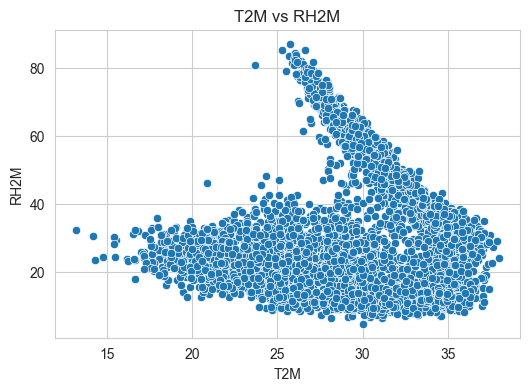

In [22]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.title("T2M vs RH2M")
plt.show()

#### Scatter: **T2M vs RH2M**

- Scatter plot shows a strong negative correlation between T2M and RH2M.
- Point distribution forms a triangular/funnel-shaped wedge.
- Relative humidity declines sharply as temperature increases.
- High humidity occurs mainly at moderate temperatures.
- Hotter conditions are associated with persistently dry air.
- Scatter suggests two atmospheric moisture regimes: humid episodes and dry baseline conditions.

### T2M_RANGE vs WS2M

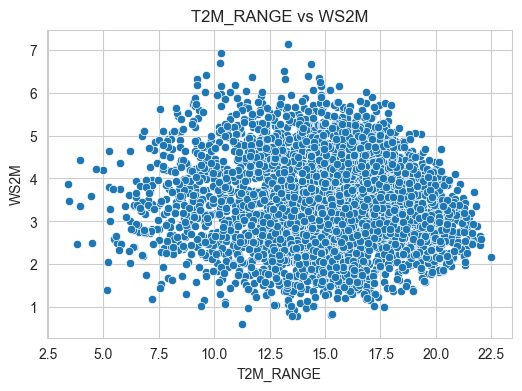

In [23]:
### Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")
plt.title("T2M_RANGE vs WS2M")
plt.show()

#### Scatter: **`T2M_RANGE` vs `WS2M`**

**1) Overall shape**

* The cloud of points looks like a **broad, slightly dome/triangular (fan-shaped) distribution**.
* It’s densest in the middle (T2M_RANGE ≈ 12–17), and tapers off toward both lower and higher temperature ranges.
* There’s a **wider vertical spread at mid-range values** and a somewhat tighter spread at the extremes—this gives it that “bulging” center.

**2) Relationship / correlation**

* There’s **no strong linear correlation**.
* If anything, there’s a **very weak negative tendency** at higher T2M_RANGE values (winds seem slightly lower on average when temperature range is large).
* But overall, the relationship looks **near-zero correlation**—WS2M varies quite a lot regardless of T2M_RANGE.

**3) Variability pattern**

* **Moderate T2M_RANGE (≈10–16):**

  * Largest spread in WS2M (from ~1 up to ~6–7).
  * Suggests more diverse wind conditions when temperature variability is moderate.
* **High T2M_RANGE (>18):**

  * WS2M values cluster more tightly (~2–4).
  * Fewer high-wind outliers.
* **Low T2M_RANGE (<8):**

  * Also somewhat scattered, but fewer points overall.

**4) Outliers**

* A few **high wind speed outliers** (~6–7 m/s) mostly around mid T2M_RANGE.
* Some **very low WS2M (<1)** scattered across ranges.


**Summary**

* **Shape:** Dome / fan-shaped cloud
* **Correlation:** Very weak to none (possibly slightly negative)
* **Key insight:** Wind speed (WS2M) is **not strongly controlled by T2M_RANGE** in this dataset, though moderate temperature ranges show the greatest variability in wind.

## 10. Distribution Analysis

In [24]:
# Calculate skewness
precip_skew = skew(df['PRECTOTCORR'])
print(f"Skewness coefficient: {precip_skew:.2f}")

Skewness coefficient: 10.28


- Since the data is highly skewed we'll use log for the Histogram.

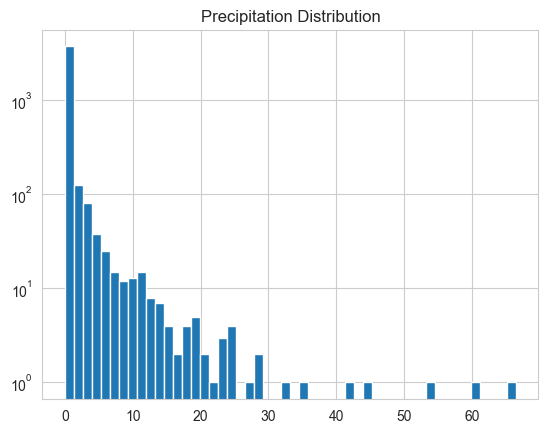

In [25]:
plt.figure()
plt.hist(df["PRECTOTCORR"].dropna(), bins=50)
plt.yscale("log") 
plt.title("Precipitation Distribution")
plt.show()

#### Histogram of **PRECTOTCORR** (log-scaled y-axis)

**Interpretation**
This is a **strongly zero-inflated, heavy-tailed** rainfall distribution:
- Most days are dry (big spike at 0).
- There’s a long right tail: when it rains, it can occasionally rain a lot.
- That combination is exactly why the log scale helps—we'e dealing with “rare events” that matter hydrologically/agronomically (runoff, flooding risk, planting success), despite being infrequent.

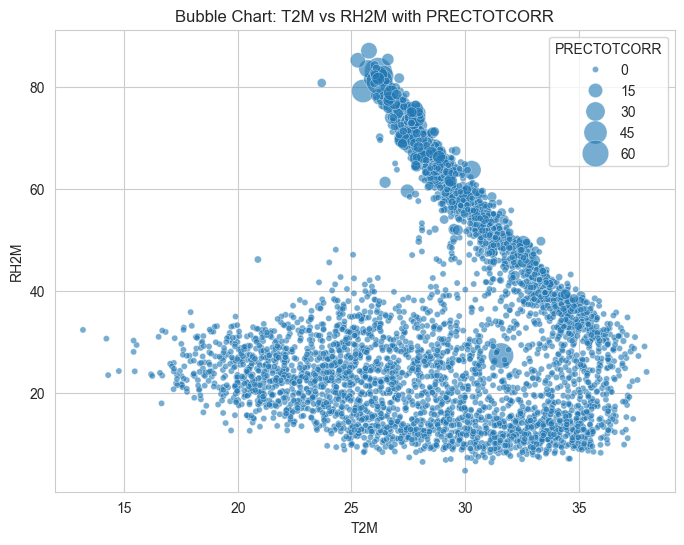

In [26]:
## bubble chart
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="T2M",
    y="RH2M",
    size="PRECTOTCORR",
    sizes=(20, 400),
    alpha=0.6,
    legend=True
)

plt.title("Bubble Chart: T2M vs RH2M with PRECTOTCORR")
plt.show()


#### Bubble chart: **T2M vs RH2M**, bubble size = **PRECTOTCORR**

#### BRANCH 1 — Upper Descending Humid Arm

*(the humid sloping branch)*

This branch roughly goes from:

* moderate temperature + very high humidity
  down to
* higher temperature + moderate humidity

---

#### Upper tip has mostly medium bubbles

> when the atmosphere is coolest and most humid, precipitation is present at moderate levels.

This is a **moist atmospheric state**, likely associated with:

* cloudy conditions,
* moist air accumulation,
* pre-rain or light rain periods.

But because bubbles are **medium, not biggest**, it suggests:

> high humidity alone does not necessarily produce the heaviest rainfall.

This is very important:

**Saturated air ≠ maximum rainfall automatically.**

It may simply represent moisture-rich stable conditions.

#### BRANCH 2 — Lower Triangular Dry Cloud

*(hotter and much drier region)*

This zone contains:

* low RH,
* broad warm temperatures,
* mostly small bubbles.

So:

> this entire lower cloud is largely a low-precipitation domain. Meaning despite temperature changes, because humidity is insufficient, rainfall remains weak or absent. This indicates dry atmospheric baseline. The air is too dry to support meaningful precipitation. So the small bubbles make perfect sense physically

